In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import networkx as nx
import scipy.stats as stats
import random
import copy
from tqdm.notebook import tqdm

# ==============================================================================
# 1. GRID & GEODATA SETUP
# ==============================================================================
def setup_microgrid():
    net = pn.case33bw()
    # Enhanced Active Grid Assets (DGs and Shunts)
    for bus in [17, 21, 24, 32]:
        pp.create_sgen(net, bus=bus, p_mw=0.2, q_mvar=0, name=f"DG_{bus+1}")
    pp.create_shunt(net, bus=17, q_mvar=-0.4, name="RPC_18")
    pp.create_shunt(net, bus=32, q_mvar=-0.6, name="RPC_33")
    
    # Coordinates centered on Linbian, Taiwan
    net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)
    G = nx.Graph()
    G.add_edges_from(net.line[['from_bus', 'to_bus']].values)
    pos = nx.kamada_kawai_layout(G)
    base_lat, base_lng = 22.434, 120.516
    for b_id, c in pos.items():
        net.bus_geodata.loc[b_id, 'x'] = base_lng + (c[0] * 0.02)
        net.bus_geodata.loc[b_id, 'y'] = base_lat + (c[1] * 0.02)
    return net

# ==============================================================================
# 2. WIND & RISK MATHEMATICS
# ==============================================================================
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def get_local_wind(dist_km, v_max, r_max=40.0):
    return v_max * (dist_km/r_max) if dist_km <= r_max else v_max * ((r_max/dist_km)**0.5)

# ==============================================================================
# 3. ROBUST MONTE CARLO SIMULATION
# ==============================================================================
# Load JMA data
df = pd.read_csv('raw/typhoon_data.csv')
top_10_ids = [201911, 201710, 200427, 201111, 200309, 200105, 201601, 199608, 200420, 200609]

MONTE_CARLO_ITERATIONS = 1000  # High robustness
MEDIAN_FAIL = 30.0            # Structural limit (m/s)
BETA = 0.15                   # Uncertainty factor

full_fault_report = []
summary_results = []

print(f"[INFO] Starting Nested Monte Carlo Simulation for {len(top_10_ids)} Typhoons")

for sid in tqdm(top_10_ids, desc="Typhoon Loop"):
    # Find peak moment for this specific storm
    storm = df[df['seq_id'] == sid].copy()
    storm['dist'] = [calculate_distance(r.lat, r.lng, 22.434, 120.516) for i, r in storm.iterrows()]
    storm['v_local'] = [get_local_wind(r.dist, r.wind) for i, r in storm.iterrows()]
    peak = storm.sort_values('v_local', ascending=False).iloc[0]
    v_peak_ms = peak.v_local * 0.5144  # knots to m/s
    
    net = setup_microgrid()
    total_demand = net.load.p_mw.sum()
    scenario_loads = []
    
    # Assign failure probabilities to lines
    net.line['pf'] = [stats.lognorm.cdf(
        max(get_local_wind(calculate_distance(peak.lat, peak.lng, net.bus_geodata.loc[l.from_bus, 'y'], net.bus_geodata.loc[l.from_bus, 'x']), v_peak_ms),
            get_local_wind(calculate_distance(peak.lat, peak.lng, net.bus_geodata.loc[l.to_bus, 'y'], net.bus_geodata.loc[l.to_bus, 'x']), v_peak_ms)),
        s=BETA, scale=MEDIAN_FAIL) for idx, l in net.line.iterrows()]

    # Monte Carlo Loop per Typhoon
    for i in tqdm(range(MONTE_CARLO_ITERATIONS), desc="Monte Carlo Loop"): 
        scen_net = copy.deepcopy(net)
        broken_lines = []
        
        for idx, line in scen_net.line.iterrows():
            if random.random() < line['pf']:
                scen_net.line.loc[idx, 'in_service'] = False
                broken_lines.append(f"{line.from_bus}-{line.to_bus}")
        
        try:
            pp.runpp(scen_net)
            served = scen_net.res_load.p_mw.sum()
        except:
            served = 0.0 # Grid Collapse
            
        scenario_loads.append(served)
        
        # Log the first iteration of each storm to the detailed fault report
        if i == 0:
            for idx, line in net.line.iterrows():
                full_fault_report.append({
                    "Typhoon_ID": sid,
                    "Line": f"L_{line.from_bus}-{line.to_bus}",
                    "Wind_Speed_ms": round(max(get_local_wind(calculate_distance(peak.lat, peak.lng, net.bus_geodata.loc[line.from_bus, 'y'], net.bus_geodata.loc[line.from_bus, 'x']), v_peak_ms),
                                               get_local_wind(calculate_distance(peak.lat, peak.lng, net.bus_geodata.loc[line.to_bus, 'y'], net.bus_geodata.loc[line.to_bus, 'x']), v_peak_ms)), 2),
                    "Failure_Prob": round(line['pf'], 4),
                    "Disrupted": "YES" if f"{line.from_bus}-{line.to_bus}" in broken_lines else "NO"
                })

    # Summary Statistics
    summary_results.append({
        "Typhoon_ID": sid,
        "Peak_Wind_ms": round(v_peak_ms, 2),
        "Avg_Load_Served_MW": round(np.mean(scenario_loads), 3),
        "Expected_Loss_MW": round(total_demand - np.mean(scenario_loads), 3),
        "Blackout_Prob_pct": round((scenario_loads.count(0.0) / MONTE_CARLO_ITERATIONS) * 100, 1)
    })

# ==============================================================================
# 4. FINAL DATA OUTPUT
# ==============================================================================
summary_df = pd.DataFrame(summary_results)
fault_df = pd.DataFrame(full_fault_report)

# Save results
summary_df.to_csv("typhoon_robust_risk_summary.csv", index=False)
fault_df.to_csv("detailed_disruption_log.csv", index=False)

print("\n--- MONTE CARLO ROBUSTNESS SUMMARY ---")
print(summary_df)

print("\n--- SAMPLE DISRUPTION TABLE (Storm 1) ---")
print(fault_df[fault_df['Typhoon_ID'] == top_10_ids[0]].head(10))

[INFO] Starting Nested Monte Carlo Simulation for 10 Typhoons


Typhoon Loop:   0%|          | 0/10 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo Loop:   0%|          | 0/1000 [00:00<?, ?it/s]


--- MONTE CARLO ROBUSTNESS SUMMARY ---
   Typhoon_ID  Peak_Wind_ms  Avg_Load_Served_MW  Expected_Loss_MW  \
0      201911         25.04               1.931             1.784   
1      201710         22.90               2.984             0.731   
2      200427         21.71               3.703             0.012   
3      201111         28.04               1.313             2.402   
4      200309         22.74               3.255             0.460   
5      200105         17.36               3.711             0.004   
6      201601         44.56               0.000             3.715   
7      199608         32.73               0.081             3.634   
8      200420         17.26               3.715             0.000   
9      200609         20.16               3.646             0.069   

   Blackout_Prob_pct  
0               10.0  
1                2.7  
2                0.1  
3               16.1  
4                1.6  
5                0.1  
6               99.6  
7               

In [2]:
fault_df[fault_df['Disrupted'] == 'YES']

,Typhoon_ID,Line,Wind_Speed_ms,Failure_Prob,Disrupted
5,201911,L_5-6,24.46,0.0870,YES
18,201911,L_18-19,24.51,0.0890,YES
26,201911,L_26-27,24.71,0.0978,YES
121,201111,L_10-11,25.04,0.1141,YES
122,201111,L_11-12,25.04,0.1141,YES
...,...,...,...,...,...
289,199608,L_30-31,32.42,0.6974,YES
291,199608,L_20-7,31.74,0.6466,YES
292,199608,L_8-14,31.91,0.6599,YES
293,199608,L_11-21,31.40,0.6194,YES


In [3]:
fault_df[fault_df['Disrupted'] == 'NO']

,Typhoon_ID,Line,Wind_Speed_ms,Failure_Prob,Disrupted
0,201911,L_0-1,24.76,0.1001,NO
1,201911,L_1-2,24.81,0.1026,NO
2,201911,L_2-3,24.81,0.1026,NO
3,201911,L_3-4,24.71,0.0980,NO
4,201911,L_4-5,24.58,0.0922,NO
...,...,...,...,...,...
365,200609,L_20-7,19.92,0.0032,NO
366,200609,L_8-14,20.08,0.0037,NO
367,200609,L_11-21,20.14,0.0040,NO
368,200609,L_17-32,19.88,0.0031,NO


In [8]:
Typhoon_ID_201911_results = fault_df[fault_df['Typhoon_ID'] == 201911]
Typhoon_ID_201911_results

,Typhoon_ID,Line,Wind_Speed_ms,Failure_Prob,Disrupted
0,201911,L_0-1,24.76,0.1001,NO
1,201911,L_1-2,24.81,0.1026,NO
2,201911,L_2-3,24.81,0.1026,NO
3,201911,L_3-4,24.71,0.0980,NO
4,201911,L_4-5,24.58,0.0922,NO
5,201911,L_5-6,24.46,0.0870,YES
6,201911,L_6-7,24.32,0.0810,NO
7,201911,L_7-8,24.20,0.0761,NO
8,201911,L_8-9,24.07,0.0710,NO
9,201911,L_9-10,23.96,0.0670,NO


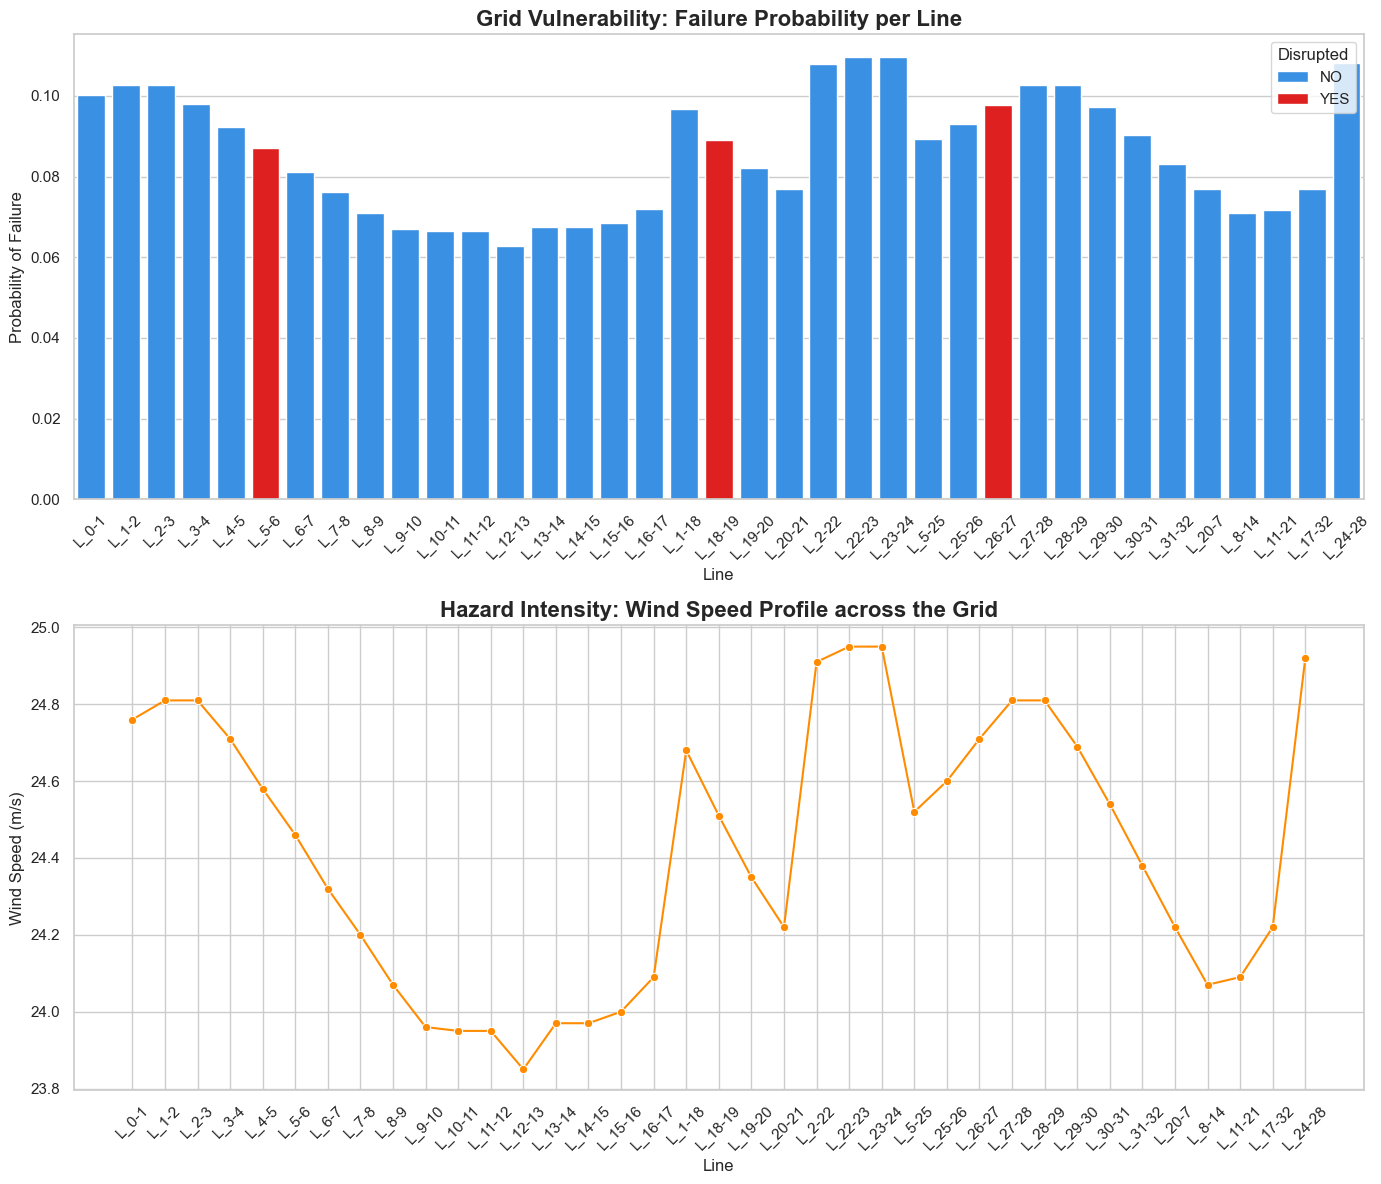

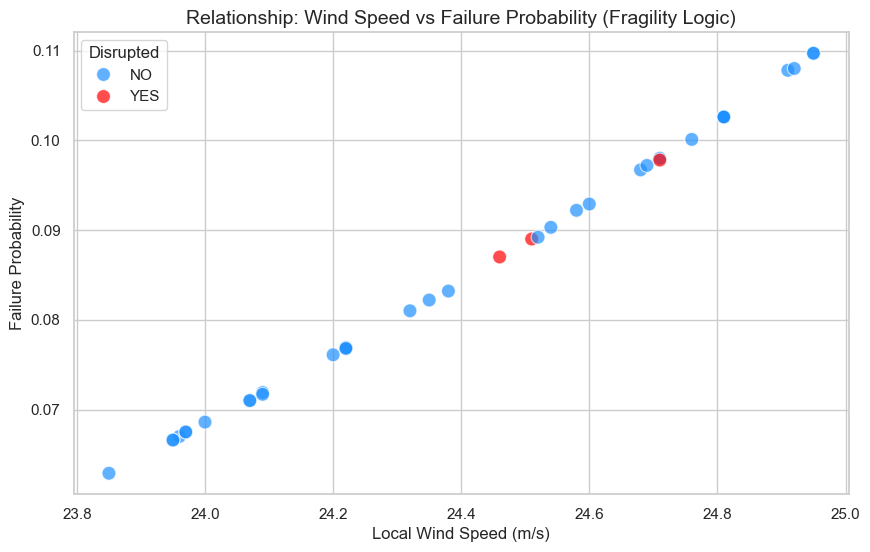

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('Typhoon_ID_201911_results.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create a multi-plot figure
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Failure Probability per Line
# We color code by disruption status (YES = Red, NO = Blue)
sns.barplot(data=df, x='Line', y='Failure_Prob', hue='Disrupted', 
            palette={'YES': 'red', 'NO': 'dodgerblue'}, ax=axes[0])
axes[0].set_title('Grid Vulnerability: Failure Probability per Line', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Probability of Failure')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Wind Speed Profile
# Shows the intensity of the typhoon across different segments of the grid
sns.lineplot(data=df, x='Line', y='Wind_Speed_ms', marker='o', color='darkorange', ax=axes[1])
axes[1].set_title('Hazard Intensity: Wind Speed Profile across the Grid', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation Plot: Wind Speed vs Failure Probability
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Wind_Speed_ms', y='Failure_Prob', hue='Disrupted', 
                s=100, palette={'YES': 'red', 'NO': 'dodgerblue'}, alpha=0.7)
plt.title('Relationship: Wind Speed vs Failure Probability (Fragility Logic)', fontsize=14)
plt.xlabel('Local Wind Speed (m/s)')
plt.ylabel('Failure Probability')
plt.show()